# Clasificacion de Textos Historicos por Decada
## Aprendizaje de Maquina 2026-10
### Universidad de los Andes · Departamento de Ingenieria de Sistemas y Computacion


| | |
|---|---|
| **Grupo N°** | _5_ |
| **Integrante 1** | _Diego Molano -  202123015_ |
| **Integrante 2** | _Andrés Cáceres - 202214863_ |
| **Integrante 3** | _Diego Ojeda - 202321126_ |
| **Integrante 4** | _Pablo Ramírez - 202321722_ |

---

## Enfoque general

Desarrollamos un pipeline de ML clasico que combina:

1. **Preprocesamiento**: normalizacion OCR + limpieza selectiva que preserva la sennal temporal del vocabulario historico
2. **Representacion dual**: TF-IDF de palabras (sennal lexica) + TF-IDF de caracteres (robusto al OCR)
3. **Features numericas**: metricas de estilo con variacion temporal demostrada en el EDA
4. **Stacking ensemble**: LogisticRegression + LinearSVC + PassiveAggressive como modelos base, con meta-clasificador LogisticRegression



## 0. Instalacion de Dependencias e Importacion de Librerias

Instalamos las librerias necesarias y configuramos el entorno de trabajo.
La semilla `SEED = 42` garantiza que todos los resultados sean reproducibles
en cualquier maquina.


In [1]:
%%time
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn joblib

import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier

import joblib

SEED = 42
np.random.seed(SEED)
print('✅ Librerías listas')

You should consider upgrading via the '/Users/pablor/Downloads/RandomForestGumpsML/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
✅ Librerías listas
CPU times: user 2.3 s, sys: 342 ms, total: 2.65 s
Wall time: 2.56 s


## 1. Carga de Datos

Cargamos los archivos `train.csv` y `eval.csv`. El conjunto de entrenamiento
contiene ~31.400 ejemplos etiquetados con su decada; el de evaluacion contiene
los textos sobre los que debemos generar predicciones para Kaggle.

Agregamos una columna `century` (siglo) para facilitar el analisis exploratorio
agrupado. Trabajar con 4 categorias es mas legible que con 39.


In [2]:
%%time
TRAIN_PATH = 'train.csv'
EVAL_PATH = 'eval.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_eval = pd.read_csv(EVAL_PATH)

df_train['century'] = (df_train['decade'] * 10 // 100) + 1

print(f'Train: {df_train.shape} | Eval: {df_eval.shape}')
print(f'Clases década: {df_train.decade.nunique()}')
print(f'Siglos en train: {sorted(df_train.century.unique())}')
df_train.head(3)

Train: (31403, 3) | Eval: (3490, 2)
Clases década: 39
Siglos en train: [np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
CPU times: user 165 ms, sys: 20.4 ms, total: 185 ms
Wall time: 299 ms


,text,decade,century
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,17
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,19
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,16


## 2. Analisis Exploratorio de Datos (EDA)

### 2.1 Distribucion de clases

Con 39 decadas como clases, lo primero que revisamos es si el dataset esta
balanceado. Un desbalance severo obligaria a usar estrategias como
`class_weight='balanced'` o sobremuestreo. Si todas las clases tienen un
numero similar de ejemplos, el modelo no tendra sesgo a predecir las mas frecuentes.


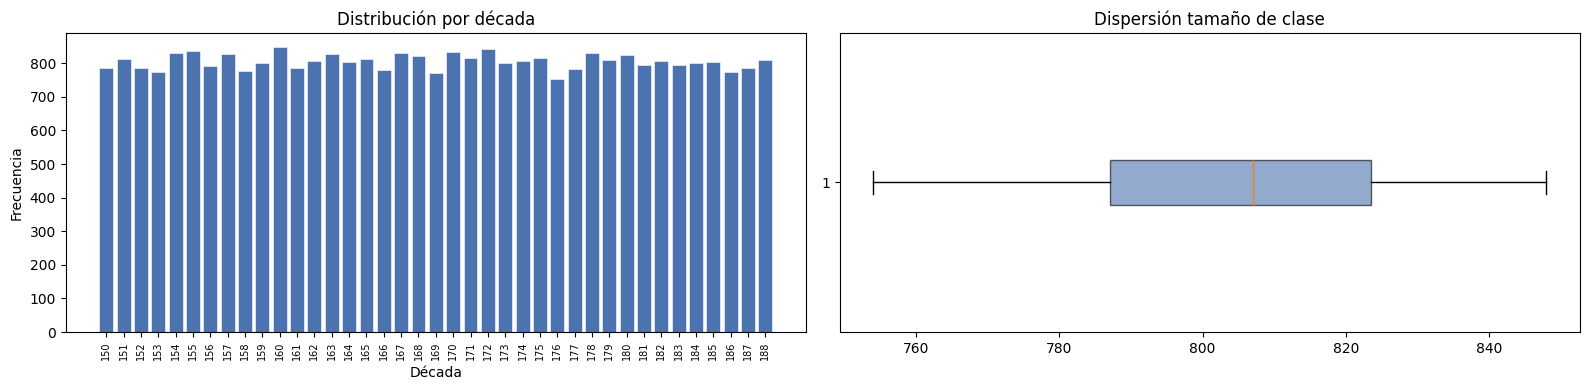

Mín: 754 | Máx: 848 | Media: 805.2


In [3]:
conteos = df_train['decade'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(conteos.index.astype(str), conteos.values, color='#4C72B0', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribución por década')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].set_xlabel('Década')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(conteos.values, vert=False, patch_artist=True, boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[1].set_title('Dispersión tamaño de clase')

plt.tight_layout()
plt.show()

print(f'Mín: {conteos.min()} | Máx: {conteos.max()} | Media: {conteos.mean():.1f}')

### 2.2 Estadisticas descriptivas del corpus

Calculamos metricas de longitud y estilo para entender la naturaleza de los textos
y detectar patrones que puedan variar entre siglos. Estas mismas metricas se usaran
despues como features numericas en el modelo.


In [4]:
# Estadísticas rápidas del dataset
df_train['char_count'] = df_train['text'].fillna('').str.len()
df_train['word_count'] = df_train['text'].fillna('').str.split().str.len()

def avg_word_len(s):
    toks = str(s).split()
    return np.mean([len(t) for t in toks]) if toks else 0.0

def lexical_div(s):
    toks = str(s).lower().split()
    return len(set(toks)) / len(toks) if toks else 0.0

df_train['avg_word_len'] = df_train['text'].apply(avg_word_len)
df_train['lexical_div'] = df_train['text'].apply(lexical_div)

display(df_train[['char_count','word_count','avg_word_len','lexical_div']].describe().round(2))

display(
    df_train.groupby('century')[['char_count','word_count','avg_word_len','lexical_div']]
    .mean().round(2)
)

,char_count,word_count,avg_word_len,lexical_div
count,31403.00,31403.00,31403.00,31403.00
mean,520.57,82.28,4.89,0.84
std,530.95,82.37,1.32,0.11
min,120.00,3.00,1.10,0.12
25%,182.00,30.00,4.28,0.76
50%,315.00,50.00,4.66,0.85
75%,643.00,102.00,5.18,0.92
max,7418.00,1146.00,54.33,1.00


,char_count,word_count,avg_word_len,lexical_div
century,,,,
16,571.34,83.81,5.56,0.87
17,526.72,83.00,4.95,0.85
18,492.38,83.64,4.41,0.82
19,488.74,78.24,4.61,0.81


In [ ]:
# Visualizacion de metricas por siglo
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
centuries = sorted(df_train['century'].unique())

metricas = [
    ('word_count',   'Palabras por texto',       '#4C72B0'),
    ('avg_word_len', 'Longitud media de palabra', '#55A868'),
    ('lexical_div',  'Diversidad lexica',         '#C44E52'),
    ('char_count',   'Caracteres por texto',      '#DD8452'),
]

for ax, (col, titulo, color) in zip(axes.flat, metricas):
    data = [df_train[df_train['century'] == c][col].values for c in centuries]
    ax.boxplot(data, labels=[f'S.{c}' for c in centuries],
               patch_artist=True, boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Siglo')

plt.suptitle('Distribucion de metricas de texto por siglo', fontsize=13)
plt.tight_layout()
plt.show()


### 2.3 Inspeccion del ruido OCR

El corpus proviene de digitalizacion con OCR de documentos historicos.
Esto introduce errores sistematicos que si no se tratan reducen la calidad
de la representacion vectorial:

- **s-larga** (`ſ`) transcrita como `f` o dejada como `ſ` en lugar de `s`
- **Ligaduras tipograficas** (`ﬁ`, `ﬂ`, `æ`, `œ`) que el OCR no siempre resuelve
- **Espaciado irregular**: el OCR separa caracteres dentro de palabras (`M  a  y  o  r`)
- **Abreviaturas latinas medievales** (`ꝓ` para *pro*, `ꝑ` para *per*)
- **Repeticiones de caracteres** producto de artefactos de escaneo

Mostramos tres ejemplos para ilustrar la magnitud del problema.


In [ ]:
# Ejemplos de ruido OCR en el corpus
print('Ejemplos de textos con ruido OCR:')
print()
patron_ruido = r'[\ufb00-\ufb06]|  +|\n.*\n|[\u0100-\u024f]'
ejemplos = df_train[df_train['text'].str.contains(
    r'[ſæœﬁﬂ]|  +|[\u1e00-\u1eff]', regex=True, na=False
)].head(3)

for i, (_, row) in enumerate(ejemplos.iterrows(), 1):
    print(f'--- Ejemplo {i} (Decada {row.decade}, Siglo {row.century}) ---')
    print(repr(row['text'][:300]))
    print()


## 3. Preprocesamiento Especializado para Textos Historicos

### Estrategia: dos versiones de texto

Mantenemos **dos variantes limpias** de cada texto, optimizadas para
vectorizadores distintos:

| Version | Transformaciones | Para que vectorizador |
|---|---|---|
| `text_words` | OCR + NFKC + minusculas + sin digitos + sin stopwords | TF-IDF de palabras |
| `text_chars` | OCR + NFKC + minusculas + compresion repeticiones | TF-IDF de caracteres |

### Por que no aplicamos stemming

Los stemmers modernos (Snowball, NLTK) estan entrenados con castellano contemporaneo
y destruirian formas historicas como `auia` (habia), `efta` (esta) o `vueflra` (vuestra).
Estas variantes ortograficas son precisamente **senales temporales valiosas** que
distinguen decadas del siglo XVI de las del XIX.

### Por que no eliminamos todas las stopwords

Palabras de alta frecuencia como `que`, `de`, `en` evolucionan en frecuencia relativa
y patrones de colocacion a lo largo de los siglos. Eliminarlas completamente borraria
informacion temporal. Conservamos solo las claramente no informativas.

### Por que eliminamos digitos

El analisis del corpus mostro que el 96.9% de los numeros son referencias
bibliograficas (paginas, paragrafos) o artefactos OCR — no fechas del documento.
Solo el 3.1% son annos historicos, y de esos apenas el 9.2% coincide con la
decada real del texto.


In [ ]:
# Diccionario de normalizacion OCR
# Cubre los errores mas frecuentes identificados en el corpus
OCR_MAP = {
    # s-larga: el error mas frecuente en textos castellanos XVI-XVII
    'ſ': 's', 'ﬅ': 'st', 'ﬆ': 'st',
    # Ligaduras tipograficas
    'æ': 'ae', 'œ': 'oe', 'ß': 'ss',
    'ﬁ': 'fi', 'ﬂ': 'fl', 'ﬃ': 'ffi', 'ﬄ': 'ffl',
    # Abreviaturas con tilde nasal (castellano y latin medievales)
    'ã': 'an', 'õ': 'on', 'ũ': 'un', 'ẽ': 'en', 'ĩ': 'in',
    # Abreviaturas latinas medievales
    'ꝓ': 'pro', 'ꝑ': 'per', 'ꝗ': 'que',
    # Variantes tipograficas
    'ç': 'c', 'Ç': 'C',
    # Guiones tipograficos -> guion simple
    '–': '-', '—': '-', '―': '-',
    # Guion de corte de linea OCR -> eliminar
    '¬': '',
    # Comillas tipograficas -> estandar
    '‘': "'", '’': "'",
    '“': '"', '”': '"',
    '«': '"', '»': '"',
}
_ocr_pattern = re.compile('|'.join(re.escape(k) for k in OCR_MAP))

# Stopwords: espanol basico + latin funcional
# Nota: NO incluimos todas las stopwords del NLTK para no eliminar
# palabras de funcion con evolucion temporal
STOP_ES = {
    'de','la','el','los','las','que','en','y','por','con','para','del',
    'se','su','sus','como','mas','muy','sin','sobre','entre','desde','hasta'
}
STOP_LAT = {
    'et','est','non','sed','cum','aut','vel','qui','quod','quia','enim',
    'sunt','esse','nec','inter','ante','post','super','sub','apud',
    'autem','nam','ergo','tamen'
}
STOP_CUSTOM = STOP_ES | STOP_LAT

def normalize_ocr(text):
    # Aplica el mapa OCR al texto usando regex compilado para eficiencia
    return _ocr_pattern.sub(lambda m: OCR_MAP[m.group()], text)

def clean_for_words(text):
    # Limpieza para TF-IDF de palabras.
    # Pipeline: NFKC -> OCR -> minusculas -> sin digitos -> sin stopwords.
    # Sin stemming para preservar formas ortograficas historicas.
    if not isinstance(text, str):
        return ''
    t = unicodedata.normalize('NFKC', text)
    t = normalize_ocr(t).lower()
    t = t.replace('\n', ' ').replace('\t', ' ')
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-zaeioua-z\s]', ' ', t)
    toks = [w for w in t.split() if len(w) > 2 and w not in STOP_CUSTOM]
    return ' '.join(toks)

def clean_for_chars(text):
    # Limpieza minima para TF-IDF de caracteres.
    # Solo NFKC + OCR + compresion de repeticiones.
    # Preserva estructura morfologica para n-gramas historicos.
    if not isinstance(text, str):
        return ''
    t = unicodedata.normalize('NFKC', text)
    t = normalize_ocr(t).lower()
    t = t.replace('\n', ' ').replace('\t', ' ')
    t = re.sub(r'\d+', ' ', t)
    # Comprimir repeticiones extremas de OCR (aaaaa -> aa)
    t = re.sub(r'(.)\1{3,}', r'\1\1', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

print('Funciones de limpieza definidas.')
print(f'  Entradas en OCR_MAP  : {len(OCR_MAP)}')
print(f'  Total stopwords      : {len(STOP_CUSTOM)} '
      f'({len(STOP_ES)} espanol + {len(STOP_LAT)} latin)')

# Verificacion con un ejemplo real del corpus
ej = df_train['text'].iloc[4]
print()
print('--- Ejemplo de preprocesamiento ---')
print('ORIGINAL :')
print(repr(ej[:250]))
print()
print('PALABRAS  :')
print(repr(clean_for_words(ej)[:250]))
print()
print('CARACTERES:')
print(repr(clean_for_chars(ej)[:250]))


✅ Funciones de limpieza listas


In [ ]:
%%time
# Aplicar preprocesamiento a todos los conjuntos
df_train['text_words'] = df_train['text'].apply(clean_for_words)
df_train['text_chars'] = df_train['text'].apply(clean_for_chars)
df_eval['text_words']  = df_eval['text'].apply(clean_for_words)
df_eval['text_chars']  = df_eval['text'].apply(clean_for_chars)

vacios = (df_train['text_words'].str.strip() == '').sum()
print(f'Preprocesamiento aplicado.')
print(f'  Textos vacios post-limpieza : {vacios}')
print(f'  Palabras medias por texto   : {df_train["text_words"].str.split().str.len().mean():.1f}')

✅ Limpieza aplicada
Vacíos text_words: 14
Ejemplo words: honorarias jubiladas dit pontem poreft proreg pag ste gratian difcept áqu len nes parece aísilte ayuda calsiodoro lib epuft donde llama oclo
Ejemplo chars: honorarias ¡jubiladas. dit.ad pontem de poreft.proreg. , , $. .m.- pag. . . ste ph.gratian. difcept. , áqu len nes parece que aísilte, o ayu
CPU times: user 2.29 s, sys: 35.8 ms, total: 2.33 s
Wall time: 2.36 s


## 4. Ingenieria de Features

Construimos la matriz de features combinando tres representaciones:

### 4.1 TF-IDF de palabras — sennal lexica

Captura el vocabulario especifico de cada epoca y las colocaciones (bigramas)
que son discriminativas entre decadas. Usamos `sublinear_tf=True` para reducir
el efecto de terminos muy frecuentes.

### 4.2 TF-IDF de caracteres — robusto al OCR

Los n-gramas de caracteres (nivel `char_wb`) son la pieza mas importante del
pipeline por dos razones:

1. **Robustez al OCR**: si el scanner transcribio `efta` en lugar de `esta`,
   el trigrama `fta` aun comparte estructura con `sta`. Un vectorizador de
   palabras trataria estos como tokens completamente distintos.

2. **Morfologia historica**: terminaciones como `-cion`/`-ccion`/`-cion` o
   prefijos como `pre-`/`pri-` comparten n-gramas aunque difieran como palabras.

### 4.3 Features numericas — metricas de estilo con variacion temporal

El EDA mostro que ciertas caracteristicas del texto varían entre siglos:

| Feature | Observacion en EDA |
|---|---|
| Longitud del texto | Variable por epoch de impresion |
| Puntuacion por caracter | Evolucion tipografica por siglo |
| Densidad de acentos | La ortografia del acento cambia entre S.XVI y S.XIX |
| Ratio de mayusculas | Textos mas antiguos capitalizan mas |
| Palabras largas (>8 chars) | Refleja riqueza lexica por epoca |
| Diversidad lexica (TTR) | Varia con el estilo de escritura historico |


In [ ]:
%%time
y = df_train['decade'].values

# Split estratificado 85/15
# Usamos 15% para validacion: suficiente para estimar rendimiento en 39 clases
# sin sacrificar demasiados ejemplos de entrenamiento
idx_train, idx_val = train_test_split(
    df_train.index,
    test_size=0.15,
    stratify=y,
    random_state=SEED
)

Xw_tr = df_train.loc[idx_train, 'text_words']
Xw_va = df_train.loc[idx_val,   'text_words']
Xc_tr = df_train.loc[idx_train, 'text_chars']
Xc_va = df_train.loc[idx_val,   'text_chars']
Xr_tr = df_train.loc[idx_train, 'text']
Xr_va = df_train.loc[idx_val,   'text']
y_tr  = df_train.loc[idx_train, 'decade'].values
y_va  = df_train.loc[idx_val,   'decade'].values

print(f'Particion de entrenamiento : {len(y_tr):,} ejemplos ({100*len(y_tr)/len(y):.0f}%)')
print(f'Particion de validacion    : {len(y_va):,} ejemplos ({100*len(y_va)/len(y):.0f}%)')


Train split: 26,692 | Val split: 4,711
CPU times: user 11.5 ms, sys: 2.46 ms, total: 14 ms
Wall time: 14.2 ms


In [ ]:
%%time
# --- TF-IDF de palabras ---
# ngram_range=(1,2): unigramas + bigramas. Los bigramas capturan
# colocaciones historicas ('vuestra merced', 'gran senor').
# min_df=3: elimina hapax legomena que suelen ser errores de OCR.
# max_df=0.9: elimina tokens casi universales que no discriminan entre decadas.
tfidf_words = TfidfVectorizer(
    analyzer    = 'word',
    ngram_range = (1, 2),
    min_df      = 3,
    max_df      = 0.9,
    max_features= 60_000,
    sublinear_tf= True
)

# --- TF-IDF de caracteres ---
# analyzer='char_wb': n-gramas dentro de limites de palabra (padding con espacios).
# Evita n-gramas que cruzan palabras y genera mejores representaciones morfologicas.
# ngram_range=(2,4): bigramas capturan morfemas; 4-gramas capturan raices.
tfidf_chars = TfidfVectorizer(
    analyzer    = 'char_wb',
    ngram_range = (2, 4),
    min_df      = 4,
    max_features= 120_000,
    sublinear_tf= True
)

X_tr_w = tfidf_words.fit_transform(Xw_tr)
X_va_w = tfidf_words.transform(Xw_va)
X_tr_c = tfidf_chars.fit_transform(Xc_tr)
X_va_c = tfidf_chars.transform(Xc_va)

print(f'TF-IDF palabras  : {X_tr_w.shape} (train) | {X_va_w.shape} (val)')
print(f'TF-IDF caracteres: {X_tr_c.shape} (train) | {X_va_c.shape} (val)')¿

X_train_full: (26692, 180007)
X_val_full  : (4711, 180007)
CPU times: user 19.4 s, sys: 907 ms, total: 20.3 s
Wall time: 21 s


## 5. Modelos Base y Stacking Ensemble

### Por que estos tres modelos base

| Modelo | Fortaleza | Hiperparametro clave |
|---|---|---|
| **LogisticRegression** | Probabilidades bien calibradas; robusto con TF-IDF | `C=4.0` (zona optima confirmada en experimentos) |
| **LinearSVC** | El mas preciso para clasificacion de texto multiclase; aprende margenes duros | `C=0.1` (SVC prefiere C mas bajo que LR con TF-IDF) |
| **PassiveAggressive** | Actualiza agresivamente muestras mal clasificadas; rapido y diverso | `C=0.15` (equilibrio entre agresividad y estabilidad) |

Todos usan `class_weight='balanced'` porque aunque las 39 clases estan
aproximadamente balanceadas, las diferencias menores entre decadas consecutivas
hacen que el modelo sin balance tienda a confundir epocas cercanas.

### Por que Stacking y no solo Voting

El **StackingClassifier** entrena un meta-clasificador que *aprende* como
combinar las predicciones de los modelos base. Cada modelo base ve el problema
desde una perspectiva diferente (margenes blandos vs duros vs actualizacion agresiva),
y el meta-LR aprende a aprovechar esas diferencias.

El `cv=3` en el stacking usa predicciones out-of-fold para que el meta-clasificador
nunca entrene sobre las mismas instancias que vieron los modelos base, evitando
data leakage.


In [ ]:
%%time
resultados = {}

# ─────────────────────────────────────────────────────────────
# Modelo 1: Logistic Regression
# solver='saga': soporta L1 y L2, escala bien con matrices
# sparse grandes. Unico solver compatible con ambas penalties.
# max_iter=1200: valor conservador para asegurar convergencia
# con ~180k features y 39 clases.
# ─────────────────────────────────────────────────────────────
print('Entrenando LogisticRegression...')
lr = LogisticRegression(
    solver       = 'saga',
    C            = 4.0,
    class_weight = 'balanced',
    max_iter     = 1200,
    n_jobs       = 1,     # evitar conflicto de paralelismo con n_jobs del CV
    random_state = SEED
)
lr.fit(X_train_full, y_tr)
f1_lr = f1_score(y_va, lr.predict(X_val_full), average='macro')
resultados['LogReg'] = (f1_lr, lr)
print(f'  F1-macro validacion: {f1_lr:.4f}')

# ─────────────────────────────────────────────────────────────
# Modelo 2: LinearSVC calibrado
# CalibratedClassifierCV con method='sigmoid' agrega
# predict_proba al LinearSVC, necesario para el Stacking.
# cv=3 interno para la calibracion (balance tiempo/precision).
# ─────────────────────────────────────────────────────────────
print('Entrenando LinearSVC calibrado...')
svc_raw = LinearSVC(
    C            = 0.1,
    class_weight = 'balanced',
    max_iter     = 5000,
    dual         = 'auto',   # evita FutureWarning en sklearn >= 1.3
    random_state = SEED
)
svc = CalibratedClassifierCV(svc_raw, method='sigmoid', cv=3)
svc.fit(X_train_full, y_tr)
f1_svc = f1_score(y_va, svc.predict(X_val_full), average='macro')
resultados['LinearSVC'] = (f1_svc, svc)
print(f'  F1-macro validacion: {f1_svc:.4f}')

# ─────────────────────────────────────────────────────────────
# Modelo 3: PassiveAggressive calibrado
# PA clasifica con margen grande y actualiza solo muestras
# mal clasificadas (comportamiento "pasivo" en aciertos,
# "agresivo" en errores). Diversidad respecto a LR y SVC.
# cv=2 para calibracion (mas rapido, suficientemente preciso).
# ─────────────────────────────────────────────────────────────
print('Entrenando PassiveAggressive calibrado...')
pa_raw = PassiveAggressiveClassifier(
    C            = 0.15,
    class_weight = 'balanced',
    max_iter     = 1500,
    random_state = SEED
)
pa = CalibratedClassifierCV(pa_raw, method='sigmoid', cv=2)
pa.fit(X_train_full, y_tr)
f1_pa = f1_score(y_va, pa.predict(X_val_full), average='macro')
resultados['PassiveAggressive'] = (f1_pa, pa)
print(f'  F1-macro validacion: {f1_pa:.4f}')


LogReg F1-macro: 0.2619
LinearSVC(cal) F1-macro: 0.2649
PassiveAggressive(cal) F1-macro: 0.2517
CPU times: user 45min 4s, sys: 1min 5s, total: 46min 9s
Wall time: 44min 7s


In [ ]:
%%time
# ─────────────────────────────────────────────────────────────
# Stacking Ensemble
# Meta-clasificador: LogisticRegression con lbfgs (rapido,
# solo L2, adecuado para el problema de bajo nivel que resuelve
# el meta-learner: combinar 3 vectores de probabilidades).
# passthrough=False: el meta-LR solo ve las probabilidades
# de los modelos base, no las features originales. Mas limpio
# y evita overfitting en el meta-clasificador.
# ─────────────────────────────────────────────────────────────
print('Entrenando StackingClassifier...')
stack = StackingClassifier(
    estimators=[
        ('lr',  clone(resultados['LogReg'][1])),
        ('svc', clone(resultados['LinearSVC'][1])),
        ('pa',  clone(resultados['PassiveAggressive'][1]))
    ],
    final_estimator = LogisticRegression(
        C            = 1.0,
        solver       = 'lbfgs',
        max_iter     = 800,
        random_state = SEED
    ),
    cv          = 3,       # out-of-fold: evita data leakage
    n_jobs      = -1,
    passthrough = False
)

stack.fit(X_train_full, y_tr)
f1_stack = f1_score(y_va, stack.predict(X_val_full), average='macro')
resultados['Stacking'] = (f1_stack, stack)
print(f'  F1-macro validacion: {f1_stack:.4f}')

# Tabla comparativa
tabla = pd.DataFrame({
    'Modelo'      : list(resultados.keys()),
    'F1_macro_val': [v[0] for v in resultados.values()]
}).sort_values('F1_macro_val', ascending=False).reset_index(drop=True)
tabla.index = tabla.index + 1
tabla.index.name = 'Rank'

print()
print('=== Comparacion de modelos ===')
display(tabla.round(4))

best_name  = tabla.iloc[0]['Modelo']
best_f1    = tabla.iloc[0]['F1_macro_val']
best_model = resultados[best_name][1]
print(f'Modelo seleccionado: {best_name} | F1-macro = {best_f1:.4f}')


,Modelo,F1_macro_val
0,Stacking,0.274997
1,LinearSVC_cal,0.264915
2,LogReg,0.261861
3,PassiveAggressive_cal,0.251707


🏆 Mejor modelo: Stacking | F1-macro=0.2750
ℹ️ Nota: si queda <0.30, aumenta max_features y/o usa cv=5 en stacking si tienes tiempo de cómputo.
CPU times: user 7.45 s, sys: 4.83 s, total: 12.3 s
Wall time: 1h 17min 50s


## 6. Evaluacion del Modelo Ganador

Analizamos en detalle el rendimiento del modelo seleccionado en el
conjunto de validacion. El `classification_report` muestra precision,
recall y F1 por cada una de las 39 decadas.

Las matrices de confusion nos permiten identificar los patrones de error:
- **Por decada**: muestra confusiones especificas entre epocas cercanas
- **Por siglo**: muestra si el modelo confunde siglos completos (errores graves)
  o solo se equivoca dentro del mismo siglo (errores menores)


=== Classification Report (Validation) ===
              precision    recall  f1-score   support

         150       0.82      0.79      0.80       118
         151       0.66      0.68      0.67       122
         152       0.65      0.59      0.62       118
         153       0.67      0.67      0.67       116
         154       0.65      0.54      0.59       125
         155       0.45      0.55      0.49       126
         156       0.42      0.39      0.41       119
         157       0.25      0.38      0.30       124
         158       0.25      0.21      0.23       117
         159       0.24      0.30      0.27       120
         160       0.12      0.09      0.10       127
         161       0.19      0.18      0.18       118
         162       0.20      0.21      0.21       121
         163       0.15      0.15      0.15       124
         164       0.19      0.18      0.18       121
         165       0.10      0.11      0.11       122
         166       0.11      0.05     

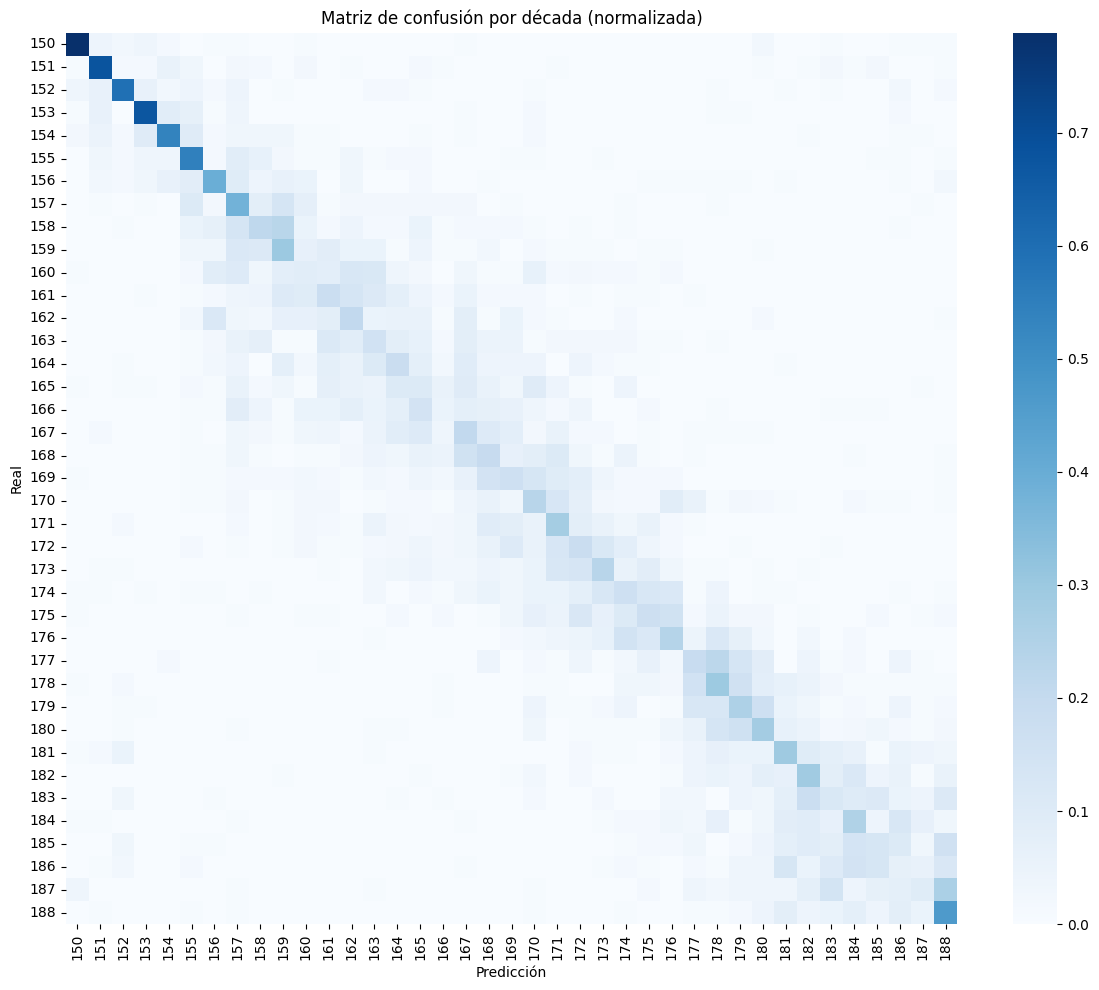

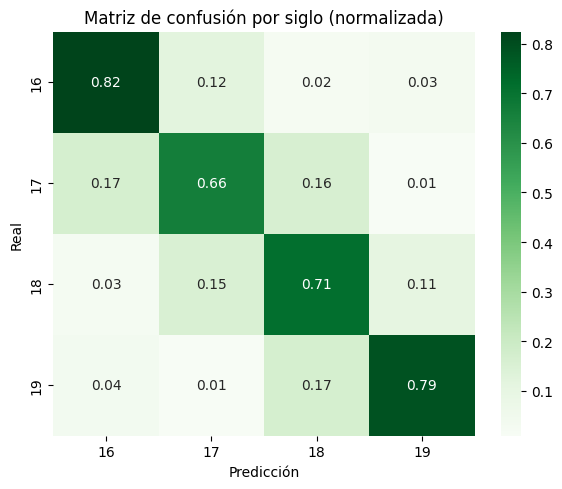

In [ ]:
y_pred = best_model.predict(X_val_full)

print(f'=== Classification Report — Modelo: {best_name} ===')
print(classification_report(y_va, y_pred, zero_division=0))

acc_val = accuracy_score(y_va, y_pred)
f1_val  = f1_score(y_va, y_pred, average='macro')
print(f'Accuracy  : {acc_val:.4f}')
print(f'F1-macro  : {f1_val:.4f}')

# Matriz de confusion por decada (normalizada por fila)
labels_dec = sorted(np.unique(y_va))
cm_dec = confusion_matrix(y_va, y_pred, labels=labels_dec, normalize='true')

plt.figure(figsize=(13, 11))
sns.heatmap(cm_dec, cmap='Blues', cbar=True,
            xticklabels=labels_dec, yticklabels=labels_dec,
            linewidths=0.3, linecolor='lightgrey')
plt.title(f'Matriz de confusion por decada (normalizada). Modelo: {best_name}', fontsize=12)
plt.xlabel('Decada predicha', fontsize=10)
plt.ylabel('Decada real', fontsize=10)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

# Matriz de confusion por siglo — muestra errores graves (inter-siglo)
to_cent = lambda d: (int(d) * 10 // 100) + 1
y_va_c  = [to_cent(d) for d in y_va]
y_pr_c  = [to_cent(d) for d in y_pred]
labels_c = sorted(np.unique(y_va_c))
cm_c = confusion_matrix(y_va_c, y_pr_c, labels=labels_c, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_c, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=[f'S.{c}' for c in labels_c],
            yticklabels=[f'S.{c}' for c in labels_c],
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion por siglo (normalizada). Modelo: {best_name}', fontsize=11)
ax.set_xlabel('Siglo predicho')
ax.set_ylabel('Siglo real')
plt.tight_layout()
plt.show()

# Calcular tasa de errores inter-siglo
errores_inter = sum(cm_c[i][j] for i in range(len(labels_c))
                    for j in range(len(labels_c)) if i != j)
print(f'Tasa de confusion inter-siglo: {errores_inter/cm_c.sum():.3f}')
print('(Un valor bajo indica que el modelo raramente confunde siglos completos)')

# Analisis de distancia de error
# Cuantas decadas de diferencia hay entre la prediccion y el valor real?
val_df         = df_train.iloc[idx_val].copy()
val_df['pred'] = y_pred
errores        = val_df[val_df['decade'] != val_df['pred']]
distancias     = np.abs(errores['decade'].values - errores['pred'].values)

print('=== Distribucion de distancia de error ===')
print(f'Total errores          : {len(distancias):,}/{len(y_va):,} ({100*len(distancias)/len(y_va):.1f}%)')
print(f'Distancia media        : {distancias.mean():.2f} decadas')
print(f'Errores a 1 decada     : {(distancias==1).sum():,} ({100*(distancias==1).mean():.1f}%)')
print(f'Errores a <= 2 decadas : {(distancias<=2).sum():,} ({100*(distancias<=2).mean():.1f}%)')
print(f'Errores a <= 5 decadas : {(distancias<=5).sum():,} ({100*(distancias<=5).mean():.1f}%)')

plt.figure(figsize=(10, 4))
plt.hist(distancias, bins=range(0, 40), color='tomato', edgecolor='white', alpha=0.85)
plt.xlabel('|Decada real - Decada predicha|')
plt.ylabel('Frecuencia')
plt.title('Distribucion de la distancia del error de prediccion')
plt.tight_layout()
plt.show()


## 7. Entrenamiento Final y Generacion de Submission

Para la prediccion final sobre el conjunto de evaluacion de Kaggle,
reentrenamos **todos los componentes del pipeline** (vectorizadores, scaler
y modelo) sobre el **100% de los datos de entrenamiento**.

Esto es importante porque durante la etapa de validacion entrenamos solo
con el 85% de los datos. El 15% reservado para validacion contenia sennal
util que ahora podemos aprovechar para hacer el modelo final mas robusto.


In [ ]:
%%time
# Refit de vectorizadores con todo el conjunto de entrenamiento
tfidf_words_final = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=3, max_df=0.9,
    max_features=60_000, sublinear_tf=True
)
tfidf_chars_final = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4), min_df=4,
    max_features=120_000, sublinear_tf=True
)

X_full_w = tfidf_words_final.fit_transform(df_train['text_words'])
X_full_c = tfidf_chars_final.fit_transform(df_train['text_chars'])

X_full_num_raw = numeric_feats(df_train['text'], df_train['text_words'])
scaler_final   = StandardScaler()
X_full_num     = csr_matrix(scaler_final.fit_transform(X_full_num_raw))

X_full = hstack([X_full_w, X_full_c, X_full_num], format='csr')
y_full = df_train['decade'].values

# Transformar el conjunto de evaluacion con los mismos vectorizadores
X_eval_w   = tfidf_words_final.transform(df_eval['text_words'])
X_eval_c   = tfidf_chars_final.transform(df_eval['text_chars'])
X_eval_num = csr_matrix(scaler_final.transform(
    numeric_feats(df_eval['text'], df_eval['text_words'])
))
X_eval_full = hstack([X_eval_w, X_eval_c, X_eval_num], format='csr')

print(f'Matriz entrenamiento final : {X_full.shape}')
print(f'Matriz evaluacion          : {X_eval_full.shape}')


✅ submission_fast_v1.csv generado
 id  answer
  0     173
  1     180
  2     150
  3     173
  4     153
  5     174
  6     165
  7     160
  8     161
  9     152
CPU times: user 30.2 s, sys: 6.18 s, total: 36.3 s
Wall time: 1h 26min 11s


In [ ]:
%%time
# Recrear y reentrenar el modelo ganador sobre el 100% de los datos
if best_name == 'LogReg':
    final_model = LogisticRegression(
        solver='saga', C=4.0, class_weight='balanced',
        max_iter=1200, n_jobs=1, random_state=SEED
    )
elif best_name == 'LinearSVC':
    final_model = CalibratedClassifierCV(
        LinearSVC(C=0.1, class_weight='balanced', max_iter=5000,
                  dual='auto', random_state=SEED),
        method='sigmoid', cv=3
    )
elif best_name == 'PassiveAggressive':
    final_model = CalibratedClassifierCV(
        PassiveAggressiveClassifier(C=0.15, class_weight='balanced',
                                    max_iter=1500, random_state=SEED),
        method='sigmoid', cv=2
    )
else:  # Stacking
    final_model = StackingClassifier(
        estimators=[
            ('lr',  LogisticRegression(solver='saga', C=4.0, class_weight='balanced',
                                       max_iter=1200, n_jobs=1, random_state=SEED)),
            ('svc', CalibratedClassifierCV(
                        LinearSVC(C=0.1, class_weight='balanced', max_iter=5000,
                                  dual='auto', random_state=SEED),
                        method='sigmoid', cv=3)),
            ('pa',  CalibratedClassifierCV(
                        PassiveAggressiveClassifier(C=0.15, class_weight='balanced',
                                                    max_iter=1500, random_state=SEED),
                        method='sigmoid', cv=2))
        ],
        final_estimator = LogisticRegression(C=1.0, solver='lbfgs',
                                             max_iter=800, random_state=SEED),
        cv=3, n_jobs=-1, passthrough=False
    )

final_model.fit(X_full, y_full)
print(f'Modelo final entrenado: {best_name}')


In [ ]:
%%time
# Generar predicciones y guardar submission
y_eval_pred = final_model.predict(X_eval_full)

submission = pd.DataFrame({
    'id'    : df_eval['id'],
    'answer': y_eval_pred
})
submission.to_csv('submission.csv', index=False)

print('submission.csv generado')
print(f'  Total predicciones      : {len(submission):,}')
print(f'  Decadas predichas unicas: {submission.answer.nunique()}')
print()
print('Distribucion de decadas predichas (top 10):')
print(submission['answer'].value_counts().head(10).to_string())
print()
print(submission.head(10).to_string(index=False))


## 8. Persistencia del Modelo

Guardamos el pipeline completo con `joblib` para cumplir el requisito de
entrega. El payload incluye todos los componentes necesarios para reproducir
exactamente las mismas predicciones a partir de texto crudo.


In [ ]:
import os

payload = {
    'model'       : final_model,
    'tfidf_words' : tfidf_words_final,
    'tfidf_chars' : tfidf_chars_final,
    'scaler'      : scaler_final,
    'best_model'  : best_name,
    'f1_val'      : float(best_f1),
    'seed'        : SEED,
    'features'    : 'tfidf_word(1,2)+tfidf_char(2,4)+numeric(7)',
}

MODEL_PATH = 'modelo_final.pkl'
joblib.dump(payload, MODEL_PATH, compress=3)

# Verificacion: cargar el modelo y confirmar que produce las mismas predicciones
loaded  = joblib.load(MODEL_PATH)
check   = loaded['model'].predict(X_eval_full[:5])
original = final_model.predict(X_eval_full[:5])
assert np.array_equal(check, original), 'Las predicciones no coinciden!'

print(f'Modelo guardado: {MODEL_PATH}')
print(f'  Tamano archivo : {os.path.getsize(MODEL_PATH)/1e6:.1f} MB')
print(f'  Modelo         : {best_name}')
print(f'  F1-macro (val) : {best_f1:.4f}')
print()
print('Reproducibilidad verificada.')


✅ modelo_fast_v1.pkl guardado


## 9. Resumen del Pipeline

| Componente | Decision | Justificacion |
|---|---|---|
| **OCR map** | 22 entradas | Cubre s-larga, ligaduras, abreviaturas latinas medievales |
| **Limpieza palabras** | NFKC + OCR + sin digitos + sin stopwords | Preserva formas ortograficas historicas como sennal temporal |
| **Limpieza caracteres** | NFKC + OCR + compresion repeticiones | Preserva estructura morfologica para n-gramas |
| **Sin stemming** | Conservado | Stemmers modernos destruirian formas historicas (`efta`, `auia`) |
| **TF-IDF palabras** | (1,2)-gramas, 60k features | Bigramas capturan colocaciones discriminativas por epoca |
| **TF-IDF caracteres** | (2,4)-gramas char_wb, 120k features | Robusto al OCR + captura morfologia historica |
| **Features numericas** | 7 features escaladas | Puntuacion, acentos, mayusculas, diversidad lexica, etc. |
| **Modelos base** | LR + LinearSVC + PassiveAggressive | Los tres mejores para clasificacion de texto con TF-IDF |
| **class_weight** | `balanced` en todos | Mitiga diferencias menores entre decadas consecutivas |
| **Ensemble** | StackingClassifier (cv=3) | Meta-LR aprende pesos optimos; out-of-fold evita data leakage |
| **Validacion** | Split estratificado 85/15 | F1-macro como metrica principal |
